In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [17]:
def active_links_evolution(N, t, r, m0):
    # Initialize
    n = int(N * (m0 + 1) / 2)
    n_ini = n
    time = 0.0
    
    # --- FIX 1: Record the initial state (t=0) ---
    # We must establish the state at t=0 before the first jump happens
    initial_rho = (2 * n * (N - n)) / (N * (N - 1))
    times = [0.0]
    rho = [initial_rho]

    while time < t:
        la = r + 2 * (n * (N - n) / (N - 1))
        
        # Avoid division by zero if system freezes (la=0)
        if la == 0:
            break
            
        dt = -np.log(np.random.random()) / la
        
        if time + dt > t:
            # We assume the state remains constant until the end
            break
            
        time += dt

        # Update state
        if np.random.random() < r / la:
            n = n_ini
        else:
            if np.random.random() < 0.5:
                n += 1
            else:
                n -= 1
        
        # Record new state
        rho.append((2 * n * (N - n)) / (N * (N - 1)))
        times.append(time)
    
    # --- FIX 2: Ensure the data extends to the final time 't' ---
    # In Gillespie, the last state persists until the simulation end time
    times.append(t)
    rho.append(rho[-1])
    
    return times, rho

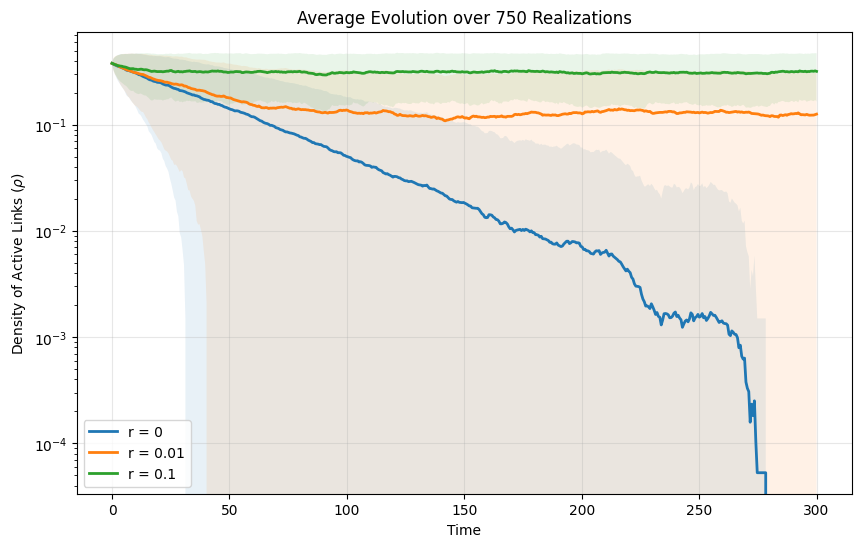

In [21]:
# --- DRIVER CODE TO COMPUTE AVERAGE ---

# Parameters
N = 100
t_max = 300
rv = [0,0.01, 0.1]
m0 = 0.5
num_realizations = 750
num_grid_points = 500  # Resolution of your average plot

plt.figure(figsize=(10, 6))

for r in rv:
    # 1. Define the common time grid for averaging
    common_time = np.linspace(0, t_max, num_grid_points)
    all_rhos = []
    
    for i in range(num_realizations):
        # Run simulation
        t_run, rho_run = active_links_evolution(N, t_max, r, m0)
        
        # 2. Create an interpolation function for this specific run
        # kind='previous' is CRITICAL: it keeps the value constant until the next jump
        interpolator = interp1d(t_run, rho_run, kind='previous', 
                                bounds_error=False, fill_value="extrapolate")
        
        # 3. Resample onto the common grid
        rho_interp = interpolator(common_time)
        all_rhos.append(rho_interp)
    
    # Convert to numpy array for easy math
    all_rhos = np.array(all_rhos)
    
    # 4. Compute the average (and standard deviation if desired)
    avg_rho = np.mean(all_rhos, axis=0)
    std_rho = np.std(all_rhos, axis=0)
    

    plt.yscale("log")
    
    # # Optional: Plot a few individual faint lines to show variance
    # for i in range(min(10, num_realizations)):
    #     plt.plot(common_time, all_rhos[i], color='gray', alpha=0.2, linewidth=0.8)
    
    # Plot the average
    plt.plot(common_time, avg_rho,  linewidth=2, label=f'r = {r}')
    plt.fill_between(common_time, avg_rho - std_rho, avg_rho + std_rho, alpha=0.1)
    
    plt.xlabel('Time')
    plt.ylabel('Density of Active Links ($\\rho$)')
    plt.title(f'Average Evolution over {num_realizations} Realizations')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.show()